<a href="https://colab.research.google.com/github/A-J-Jovia/jovia-codeboosters-2026/blob/main/Day10/day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TO DOs**

1.  Use CSV to Pandas
2.  Use SQL to retrive data and Use Matplotlib
3.  Transform the data
4.  PySpark(Medallian arch)
5.  Use ML to predict.
6.  Deploy everything in GitHub

In [2]:
import pandas as pd
df = pd.read_csv("student_performance.csv")
print(f"Columns: {df.columns.tolist()}")
print(f"\nShape: {df.shape}")
display(df.head())

Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

Shape: (30, 13)


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [3]:
import os

if os.path.exists("Marks.db"):
    os.remove("Marks.db")

In [4]:
import sqlite3

conn = sqlite3.connect('Marks.db')
cursor = conn.cursor()
df.to_sql('students', conn, if_exists='replace', index=False)
cursor.execute("SELECT student_id, name FROM students LIMIT 5")
rows = cursor.fetchall()
for row in rows:
    print(row)

(1001, 'Aarav Sharma')
(1002, 'Priya Patel')
(1003, 'Rohit Verma')
(1004, 'Sneha Reddy')
(1005, 'Arjun Nair')


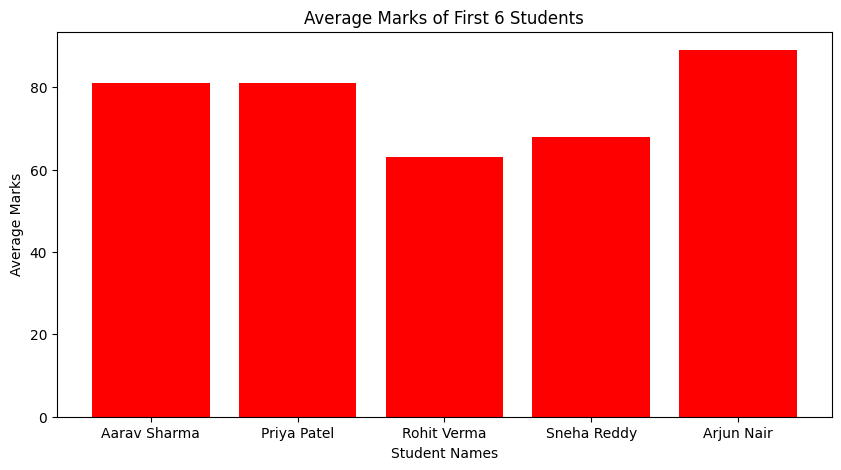

In [5]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

df = pd.read_csv("student_performance.csv")

df['average'] = (df['math_score']+df['science_score']+df['english_score']+df['programming_score'])// 4
first6 = df.head()
plt.figure(figsize=(10, 5))
plt.bar(first6['name'], first6['average'],color='red')
plt.xlabel('Student Names')
plt.ylabel('Average Marks')
plt.title('Average Marks of First 6 Students')
plt.show()

In [6]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df.loc[[0,5,17,18,25], 'city'] = np.nan
df.loc[[1,6,18,19,26], 'admission_year'] = np.nan

print("Before fixing nulls:", df.isnull().sum().sum(),"total missing values")
print(df[['city','admission_year']].isnull().sum())
df['city'].fillna('Unknown City', inplace=True)
print(f"\nFilled missing City with 'Unknown City'")

df['admission_year'].fillna(2023, inplace=True)
print(f"\nFilled missing Admission year with 2023")

print("\nAfter fixing nulls:", df.isnull().sum().sum(),"total missing values")

Before fixing nulls: 10 total missing values
city              5
admission_year    5
dtype: int64

Filled missing City with 'Unknown City'

Filled missing Admission year with 2023

After fixing nulls: 0 total missing values


In [7]:
import requests

API_KEY = '4cd2754214fa45c03f9c355bb38c8ad9'
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
CITIES = ['Madurai', 'Tirupur', 'Bangalore', 'Chennai', 'Coimbatore']

print(f"API configured for {len(CITIES)} cities")
print(f"Cities: {CITIES}")

API configured for 5 cities
Cities: ['Madurai', 'Tirupur', 'Bangalore', 'Chennai', 'Coimbatore']


In [8]:
def fetch_weather(city, api_key):
  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  response = requests.get(BASE_URL, params=params, timeout=10)
  if response.status_code == 200:
    data = response.json()
    return {
        'city' : city,
        'temperature' : round(data['main']['temp'],1),
        'feels_like'  : round(data['main']['feels_like'],1),
        'wind_speed'  : data['wind']['speed'],
        'condition'   : data['weather'][0]['description'].title()
    }

  print('Calling Weather API...')
  weather_records =[]

  for city in CITIES:
    print(f" Fetching: {city}...", end='')
    record = fetch_weather(city, API_KEY)
    if record:
      weather_records.append(record)
      print(f" {record["temperature"]}°C, {record["condition"]}")
    else:
      print("FAILED")

  print(f"\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities")


In [9]:
print('Calling Weather API...')
weather_records =[]

for city in CITIES:
  print(f" Fetching: {city}...", end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f" {record["temperature"]}°C, {record["condition"]}")
    print("{")
    for key, value in record.items():
      print(f"  {key} : {value}")
    print("}\n")
  else:
    print("FAILED")

print(f"\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities")

Calling Weather API...
 Fetching: Madurai... 35.5°C, Overcast Clouds
{
  city : Madurai
  temperature : 35.5
  feels_like : 36.9
  wind_speed : 6.13
  condition : Overcast Clouds
}

 Fetching: Tirupur... 32.4°C, Overcast Clouds
{
  city : Tirupur
  temperature : 32.4
  feels_like : 34.3
  wind_speed : 8.93
  condition : Overcast Clouds
}

 Fetching: Bangalore... 29.4°C, Overcast Clouds
{
  city : Bangalore
  temperature : 29.4
  feels_like : 31.8
  wind_speed : 7.5
  condition : Overcast Clouds
}

 Fetching: Chennai... 39.3°C, Overcast Clouds
{
  city : Chennai
  temperature : 39.3
  feels_like : 46.3
  wind_speed : 1.79
  condition : Overcast Clouds
}

 Fetching: Coimbatore... 31.1°C, Overcast Clouds
{
  city : Coimbatore
  temperature : 31.1
  feels_like : 32.8
  wind_speed : 7.74
  condition : Overcast Clouds
}


Successfully fetched: 5/5 cities


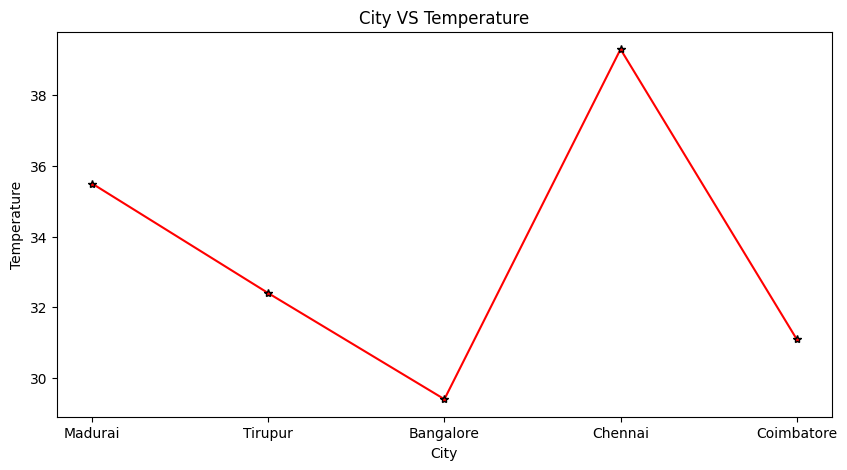

In [10]:
df = pd.DataFrame(weather_records)

plt.figure(figsize=(10, 5))
plt.plot(df['city'], df['temperature'],color='red',marker="*",markeredgecolor="black")
plt.xlabel('City')
plt.ylabel('Temperature')
plt.title('City VS Temperature')
plt.show()

In [11]:
import pandas as pd

df_bronze = pd.read_csv("student_performance.csv")

print("BRONZE LAYER")
print(f"Rows: {df_bronze.shape[0]}")
print(f"Columns: {df_bronze.shape[1]}")
print(f"Column Names: {df_bronze.columns.tolist()}")

display(df_bronze.head())

df_bronze.to_csv("students_bronze.csv", index=False)
print("Bronze layer saved successfully")

BRONZE LAYER
Rows: 30
Columns: 13
Column Names: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


Bronze layer saved successfully


In [12]:
import numpy as np

df_silver = df_bronze.copy()

# Simulate missing values
df_silver.loc[[0,5,17,18,25], 'city'] = np.nan
df_silver.loc[[1,6,18,19,26], 'admission_year'] = np.nan

# Remove duplicates
df_silver = df_silver.drop_duplicates()

# Fix missing values
df_silver['city'].fillna('Unknown City', inplace=True)
df_silver['admission_year'].fillna(2023, inplace=True)

# Add Average Marks Column
df_silver['average_marks'] = (df_silver['math_score']+ df_silver['science_score']+ df_silver['english_score']+ df_silver['programming_score']) / 4

print("SILVER LAYER")
print(f"Rows: {df_silver.shape[0]}")
print(f"Missing Values: {df_silver.isnull().sum().sum()}")

display(df_silver.head())

df_silver.to_csv("students_silver.csv", index=False)
print("Silver layer saved successfully")

SILVER LAYER
Rows: 30
Missing Values: 0


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year,average_marks
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Unknown City,2023.0,81.50
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023.0,81.25
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023.0,63.75
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023.0,68.25
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023.0,89.00


Silver layer saved successfully


In [13]:
gold_top_students = (
    df_silver[['student_id','name','average_marks']]
    .sort_values('average_marks', ascending=False)
    .head(10)
)

print("GOLD LAYER - TOP STUDENTS")

display(gold_top_students)

GOLD LAYER - TOP STUDENTS


,student_id,name,average_marks
9,1010,Ananya Das,92.75
21,1022,Tanvi Mehta,91.75
29,1030,Akanksha Yadav,91.25
4,1005,Arjun Nair,89.00
7,1008,Divya Singh,89.00
17,1018,Swati Kulkarni,88.50
24,1025,Amit Bose,84.00
12,1013,Suresh Rao,83.50
19,1020,Nisha Kapoor,81.75
0,1001,Aarav Sharma,81.50


In [14]:
gold_city_performance = (
    df_silver
    .groupby('city')['average_marks']
    .mean()
    .reset_index()
    .sort_values('average_marks', ascending=False)
)

print("GOLD LAYER - CITY PERFORMANCE")

display(gold_city_performance)

GOLD LAYER - CITY PERFORMANCE


,city,average_marks
17,Surat,91.750
12,Kochi,89.000
13,Kolkata,88.375
0,Agra,86.250
14,Lucknow,85.125
15,Mysore,83.500
5,Chandigarh,81.750
1,Ahmedabad,81.250
6,Chennai,73.750
20,Unknown City,73.150


In [15]:
gold_year_performance = (
    df_silver
    .groupby('admission_year')['average_marks']
    .mean()
    .reset_index()
)

print("GOLD LAYER - YEAR PERFORMANCE")

display(gold_year_performance)

gold_top_students.to_csv("gold_top_students.csv", index=False)
gold_city_performance.to_csv("gold_city_performance.csv", index=False)
gold_year_performance.to_csv("gold_year_performance.csv", index=False)
print("Gold layer datasets saved successfully")

GOLD LAYER - YEAR PERFORMANCE


,admission_year,average_marks
0,2023.0,73.916667


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All ML Libraries imported successfully")

All ML Libraries imported successfully


In [17]:
df_ml = df_silver.copy()

le_gender = LabelEncoder()
df_ml['gender_encoded'] = le_gender.fit_transform(df_ml['gender'])

print(
    f"Gender encoding: "
    f"{dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

le_department = LabelEncoder()
df_ml['department_encoded'] = le_department.fit_transform(df_ml['department'])

print(
    f"Department encoding: "
    f"{dict(zip(le_department.classes_, le_department.transform(le_department.classes_)))}"
)

display(df_ml[['gender', 'gender_encoded', 'department', 'department_encoded']].head())

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}
Department encoding: {'Civil': np.int64(0), 'Computer Science': np.int64(1), 'Electronics': np.int64(2), 'Mechanical': np.int64(3)}


,gender,gender_encoded,department,department_encoded
0,Male,1,Computer Science,1
1,Female,0,Computer Science,1
2,Male,1,Electronics,2
3,Female,0,Mechanical,3
4,Male,1,Computer Science,1


In [18]:
feature_cols = [
    'math_score',
    'science_score',
    'english_score',
    'attendance_percentage',
    'gender_encoded',
    'department_encoded'
]

X = df_ml[feature_cols]
y = df_ml['programming_score']

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nFeature Columns: {feature_cols}")
print("Target Column: programming_score")
print(
    f"\nTarget Range: "
    f"{y.min()} to {y.max()} "
    f"(mean: {y.mean():.1f})"
)

Feature matrix X shape: (30, 6)
Target vector y shape: (30,)

Feature Columns: ['math_score', 'science_score', 'english_score', 'attendance_percentage', 'gender_encoded', 'department_encoded']
Target Column: programming_score

Target Range: 38 to 97 (mean: 67.6)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

print(f"Total Students: {X.shape[0]}")
print(f"Training Students: "f"{len(X_train)} "f"({len(X_train)/len(X)*100:.0f}%)")

print(
    f"Testing Students: "
    f"{len(X_test)} "
    f"({len(X_test)/len(X)*100:.0f}%)"
)

print(
    f"Training Target Range: "
    f"{y_train.min()} - {y_train.max()}"
)

print(
    f"Testing Target Range: "
    f"{y_test.min()} - {y_test.max()}"
)

Total Students: 30
Training Students: 24 (80%)
Testing Students: 6 (20%)
Training Target Range: 38 - 96
Testing Target Range: 39 - 97


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(
    f"Training Feature Mean: "
    f"{X_train_scaled.mean():.4f}"
)

print(
    f"Training Feature Std: "
    f"{X_train_scaled.std():.4f}"
)

Features scaled successfully!
Training Feature Mean: -0.0000
Training Feature Std: 1.0000


In [23]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("=== Model 1: Linear Regression ===")
print(f"MAE: {lr_mae:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"R2 Score: {lr_r2:.4f}")
print()
print("Learned Coefficients:")

for feat, coef in zip(feature_cols, lr_model.coef_):
    print(f"{feat:<25}: {coef:+.3f}")

print(
    f"\nBias (Intercept): "
    f"{lr_model.intercept_:.3f}"
)

=== Model 1: Linear Regression ===
MAE: 9.3707
RMSE: 11.4690
R2 Score: 0.7356

Learned Coefficients:
math_score               : +20.256
science_score            : +7.612
english_score            : +2.396
attendance_percentage    : -12.886
gender_encoded           : -0.397
department_encoded       : -0.449

Bias (Intercept): 68.042


In [24]:
dt_model = DecisionTreeRegressor(max_depth=5,random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
dt_mae = mean_absolute_error(y_test,dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test,dt_pred)

print("=== Model 2: Decision Tree Regressor ===")
print(f"MAE: {dt_mae:.4f}")
print(f"RMSE: {dt_rmse:.4f}")
print(f"R2 Score: {dt_r2:.4f}")

=== Model 2: Decision Tree Regressor ===
MAE: 10.7500
RMSE: 16.0792
R2 Score: 0.4803


In [25]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train_scaled,y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test,rf_pred)
print("=== Model 3: Random Forest Regressor ===")
print(f"MAE: {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R2 Score: {rf_r2:.4f}")

=== Model 3: Random Forest Regressor ===
MAE: 10.6050
RMSE: 13.9655
R2 Score: 0.6079


=== Model Comparison ===


,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.37067,11.469004,0.735587
2,Random Forest,10.60500,13.965547,0.607945
1,Decision Tree,10.75000,16.079231,0.480289


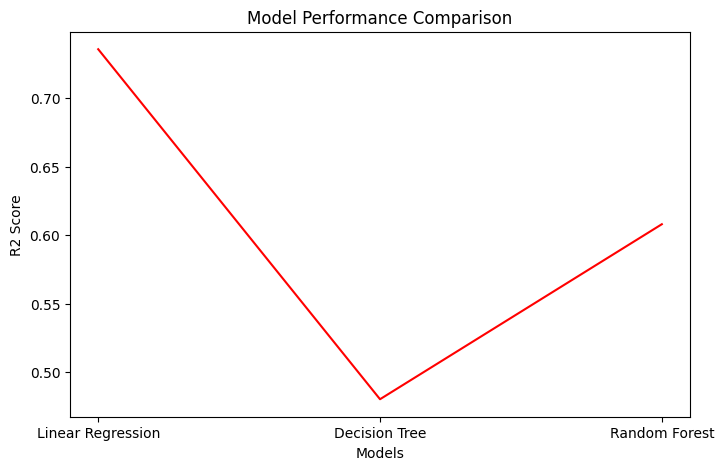

In [29]:
results = pd.DataFrame({
    'Model': ['Linear Regression','Decision Tree','Random Forest'],
    'MAE': [lr_mae,dt_mae,rf_mae],
    'RMSE': [lr_rmse,dt_rmse,rf_rmse],
    'R2 Score': [lr_r2,dt_r2,rf_r2]})
print("=== Model Comparison ===")
display(results.sort_values('R2 Score',ascending=False))

plt.figure(figsize=(8,5))
plt.plot(results['Model'],results['R2 Score'],color='red')
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison")
plt.show()